# Statistical Validation and Uncertainty

**Business question:** Are the main operational findings large and stable enough to support decisions?

This notebook answers four questions:

1. **How precise are the headline rates?**
2. **Are the important business gaps clearly larger than sampling uncertainty?**
3. **Does delay severity remain associated with negative reviews after adjustment?**
4. **Do reasonable sensitivity checks change the conclusion?**

All populations come from certified KPI fields and approved upstream analyses. Results are observational associations, not causal effects.


In [6]:
from pathlib import Path
import sys

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from python.scripts.config import ANALYSIS_OUTPUT_DIR

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

intervals = pd.read_csv(ANALYSIS_OUTPUT_DIR / "review_effect_estimates.csv")
comparisons = pd.read_csv(ANALYSIS_OUTPUT_DIR / "group_comparisons.csv")
bootstrap = pd.read_csv(ANALYSIS_OUTPUT_DIR / "bootstrap_estimates.csv")
model = pd.read_csv(ANALYSIS_OUTPUT_DIR / "review_outcome_model.csv")
diagnostics = pd.read_csv(ANALYSIS_OUTPUT_DIR / "review_outcome_diagnostics.csv")
sensitivity = pd.read_csv(ANALYSIS_OUTPUT_DIR / "statistical_sensitivity.csv")
missingness = pd.read_csv(ANALYSIS_OUTPUT_DIR / "inference_missingness.csv")

print(f"Rate estimates: {len(intervals)}")
print(f"Business comparisons: {len(comparisons)}")
print(f"Bootstrap resamples: {int(bootstrap.n_bootstrap.iloc[0]):,}")


Rate estimates: 18
Business comparisons: 5
Bootstrap resamples: 2,000


## 1. How precise are the headline rates?

Confidence intervals put uncertainty around the descriptive findings already established upstream.

The goal is not to test every KPI. It is to confirm that the most important rates are estimated precisely enough to support operational interpretation.


In [7]:
headline_names = [
    "marketplace_late_comparable",
    "negative_review_early",
    "negative_review_on_time",
    "negative_review_late",
]

headline = (
    intervals.set_index("estimate")
    .loc[headline_names, ["numerator", "denominator", "rate", "ci_low", "ci_high"]]
)
display(headline)


,numerator,denominator,rate,ci_low,ci_high
estimate,,,,,
marketplace_late_comparable,6509,95453,0.068,0.067,0.070
negative_review_early,7945,87203,0.091,0.089,0.093
negative_review_on_time,155,1264,0.123,0.106,0.142
negative_review_late,3932,6307,0.623,0.611,0.635


## 2. Are the important gaps larger than uncertainty?

The most useful quantities are **differences in rates**, not p-values alone.

This section checks the main findings from the earlier analyses:

- late versus early customer reviews;
- even a small 1–3 day delay versus early delivery;
- reviewed versus unreviewed delivery performance;
- February–March 2018 versus the early baseline;
- watchlist versus non-watchlist seller performance.


,left_rate,right_rate,difference,ci_low,ci_high
comparison,,,,,
late_vs_early_negative,0.623,0.091,0.532,0.520,0.544
late_1_3_vs_early_negative,0.320,0.091,0.229,0.207,0.250
unreviewed_vs_reviewed_late,0.134,0.067,0.067,0.051,0.084
feb_mar_2018_vs_early_baseline,0.166,0.035,0.131,0.124,0.138
watchlist_vs_nonwatchlist,0.092,0.062,0.029,0.024,0.034


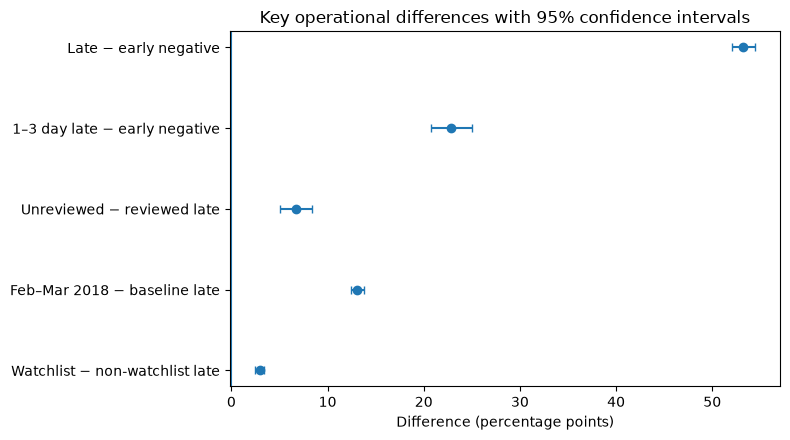

,point_estimate,ci_low,ci_high,n_bootstrap
quantity,,,,
late_minus_early_negative,0.532,0.520,0.545,2000
unreviewed_minus_reviewed_late,0.067,0.051,0.083,2000


In [8]:
comparison_names = [
    "late_vs_early_negative",
    "late_1_3_vs_early_negative",
    "unreviewed_vs_reviewed_late",
    "feb_mar_2018_vs_early_baseline",
    "watchlist_vs_nonwatchlist",
]

gaps = (
    comparisons.set_index("comparison")
    .loc[comparison_names, [
        "left_rate",
        "right_rate",
        "difference",
        "ci_low",
        "ci_high",
    ]]
)
display(gaps)

plot_data = gaps.iloc[::-1]
y = range(len(plot_data))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    plot_data["difference"] * 100,
    y,
    xerr=[
        (plot_data["difference"] - plot_data["ci_low"]) * 100,
        (plot_data["ci_high"] - plot_data["difference"]) * 100,
    ],
    fmt="o",
    capsize=3,
)
ax.axvline(0, linewidth=0.8)
ax.set_yticks(list(y), [
    "Watchlist − non-watchlist late",
    "Feb–Mar 2018 − baseline late",
    "Unreviewed − reviewed late",
    "1–3 day late − early negative",
    "Late − early negative",
])
ax.set(
    xlabel="Difference (percentage points)",
    title="Key operational differences with 95% confidence intervals",
)
fig.tight_layout()
plt.show()

display(
    bootstrap.set_index("quantity")[
        ["point_estimate", "ci_low", "ci_high", "n_bootstrap"]
    ]
)


## 3. Does delay severity remain associated with negative reviews after adjustment?

The logistic model adjusts for:

- order-value band;
- customer-state group;
- first versus repeat purchase;
- multi-seller orders.

Early delivery is the reference category.

The model is used for **adjusted association**, not causal attribution.


,population,orders,late_rate
0,delivery_performance_eligible,96470,0.068
1,reviewed_eligible_model,94774,0.067
2,unreviewed_eligible_excluded,1696,0.134


,value
n_model,94774
n_negative,12032
negative_share,0.127
n_late,6307
converged,True
pseudo_r2,0.169
reference_categories,early; GMV<50; SP
note,Unreviewed eligible orders are excluded becaus...


,odds_ratio,or_ci_low,or_ci_high,p_value
term,,,,
on_time,1.470,1.240,1.744,0.000
late_1_3,4.922,4.447,5.448,0.000
late_4_7,21.630,19.497,23.996,0.000
late_8_14,41.706,36.511,47.640,0.000
late_15_30,44.556,37.825,52.484,0.000
late_31plus,20.875,16.477,26.447,0.000


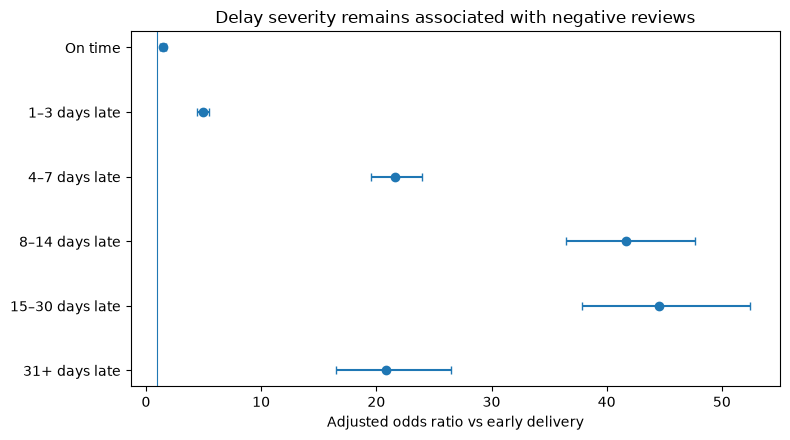

In [9]:
display(missingness)
display(diagnostics.T.rename(columns={0: "value"}))

model_view = model.set_index("term")[
    ["odds_ratio", "or_ci_low", "or_ci_high", "p_value"]
]
display(model_view)

plot_data = model_view.iloc[::-1]
labels = {
    "on_time": "On time",
    "late_1_3": "1–3 days late",
    "late_4_7": "4–7 days late",
    "late_8_14": "8–14 days late",
    "late_15_30": "15–30 days late",
    "late_31plus": "31+ days late",
}

y = range(len(plot_data))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    plot_data["odds_ratio"],
    y,
    xerr=[
        plot_data["odds_ratio"] - plot_data["or_ci_low"],
        plot_data["or_ci_high"] - plot_data["odds_ratio"],
    ],
    fmt="o",
    capsize=3,
)
ax.axvline(1, linewidth=0.8)
ax.set_yticks(list(y), [labels[x] for x in plot_data.index])
ax.set(
    xlabel="Adjusted odds ratio vs early delivery",
    title="Delay severity remains associated with negative reviews",
)
fig.tight_layout()
plt.show()


## 4. Do reasonable sensitivity checks change the conclusion?

The analysis is repeated after:

- restricting to the comparable time window;
- removing 31+ day delays;
- removing the top 1% of delays.

The question is whether the **late-versus-early review gap remains large**, not whether every estimate is identical.


In [10]:
display(
    sensitivity.set_index("slice")[
        [
            "n",
            "late_reviewed",
            "early_reviewed",
            "late_negative_rate",
            "early_negative_rate",
            "rate_difference",
        ]
    ]
)


,n,late_reviewed,early_reviewed,late_negative_rate,early_negative_rate,rate_difference
slice,,,,,,
all_reviewed_eligible,94774,6307,87203,0.623,0.091,0.532
comparable_window,93799,6283,86253,0.623,0.091,0.532
exclude_late_31plus,94452,5985,87203,0.620,0.091,0.529
exclude_p99_delay,93869,5402,87203,0.597,0.091,0.506


## Takeaways

- **The headline rates are estimated precisely.** Their confidence intervals are narrow relative to the size of the observed differences.
- **The major operational gaps are much larger than sampling uncertainty.** This includes the late-versus-early review gap, the February–March fulfillment deterioration, and the seller-watchlist difference.
- **Even small delivery misses matter.** A 1–3 day delay is already associated with substantially worse review outcomes than early delivery.
- **Delay severity remains associated with negative reviews after adjustment** for order value, geography, repeat purchase, and multi-seller orders.
- **Reasonable exclusions do not remove the main customer-experience result.** Extreme delays amplify the problem but do not create it.

These results strengthen the earlier operational findings, but they remain observational and should not be interpreted as causal effects or seller-level blame.
